In [69]:
"""
Interactive Markov State Model builder: Load count matrices and convert to transition matrices.
"""
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from deeptime.markov.msm import MarkovStateModel
from deeptime.markov.msm import MaximumLikelihoodMSM
from deeptime.markov import TransitionCountModel
from deeptime.plots import plot_implied_timescales
from deeptime.util.validation import ImpliedTimescales

np.set_printoptions(linewidth=np.inf, precision=6, suppress=True)

def count_matrix_path(beta: float, h: float, rc: str, c_matrix_in: str | None = None) -> Path:
    """Resolve the count-matrix NPZ path for a parameter set."""
    if c_matrix_in is not None:
        data_path = Path(c_matrix_in)
    else:
        data_path = Path("data") / f"C_matrices_{beta:.3f}_{h:.3f}_{rc}.npz"
        if not data_path.exists() and rc == "cnn":
            legacy = Path("data") / f"C_matrices_{beta:.3f}_{h:.3f}.npz"
            if legacy.exists():
                data_path = legacy

    if not data_path.exists():
        raise FileNotFoundError(f"Missing count-matrix file: {data_path}")
    return data_path


def available_count_lags(beta: float, h: float, rc: str, c_matrix_in: str | None = None) -> list[int]:
    """Return all lag times available in a count-matrix NPZ file."""
    data_path = count_matrix_path(beta, h, rc, c_matrix_in=c_matrix_in)
    with np.load(str(data_path)) as data:
        return sorted(int(k.split("m")[-1]) for k in data.keys() if k.startswith("C_m"))


def load_count_matrix(beta: float, h: float, rc: str, m: int, c_matrix_in: str | None = None) -> np.ndarray:
    """Load a specific count matrix from NPZ file."""
    data_path = count_matrix_path(beta, h, rc, c_matrix_in=c_matrix_in)

    data = np.load(str(data_path))
    
    # Get list of available lags
    m_list = sorted(int(k.split("m")[-1]) for k in data.keys() if k.startswith("C_m"))
    
    if m not in m_list:
        print(f"Available lags: {m_list}")
        raise ValueError(f"Lag m={m} not found in count matrix file")
    
    return np.asarray(data[f"C_m{m}"], dtype=float)


def count_to_transition(C: np.ndarray, normalize_rows: bool = True) -> np.ndarray:
    """
    Convert count matrix to transition matrix.
    
    Args:
        C: Count matrix (n_states, n_states)
        normalize_rows: If True, normalize by row sums. If False, normalize by total sum.
    
    Returns:
        Transition matrix P
    """
    C = np.asarray(C, dtype=float)
    
    if normalize_rows:
        # Row normalization: P[i,j] = C[i,j] / sum(C[i,:])
        row_sums = C.sum(axis=1, keepdims=True)
        with np.errstate(divide="ignore", invalid="ignore"):
            P = np.where(row_sums > 0, C / row_sums, 0.0)
    else:
        # Column normalization: P[i,j] = C[i,j] / sum(C[:,j])
        col_sums = C.sum(axis=0, keepdims=True)
        with np.errstate(divide="ignore", invalid="ignore"):
            P = np.where(col_sums > 0, C / col_sums, 0.0)
    
    return P


def load_brute_force_rate(beta: float, h: float, nucleation_dir: str = "data") -> float:
    """
    Load brute force nucleation rate from nucleation rate files.
    
    Args:
        beta: Beta parameter
        h: H parameter
        nucleation_dir: Directory containing nucleation rate files
    
    Returns:
        Nucleation rate (float)
    """
    # Try to load from nucleation_rates NPZ file
    nuc_path = Path(nucleation_dir) / f"nucleation_{beta:.3f}_{h:.3f}.npz"
    
    if nuc_path.exists():
        data = np.load(str(nuc_path))
        J_brute = float(np.atleast_1d(data["rate_per_site"])[0])
        return J_brute

    raise FileNotFoundError(f"Could not find nucleation rate for beta={beta:.3f}, h={h:.3f}")


def deeptime_out_path(out_dir, beta, h, rc):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    return out_dir / f"msm_analysis_{beta:.3f}_{h:.3f}_{rc}.npz"


def save_deeptime_record(record, out_path):
    np.savez(
        str(out_path),
        beta=np.float64(record["beta"]),
        h=np.float64(record["h"]),
        rc=np.asarray(record["rc"], dtype=str),
        selected_m=np.int64(record["selected_m"]),
        coarse_lagtimes=np.asarray(record["coarse_lagtimes"], dtype=np.int64),
        coarse_N=np.asarray(record["coarse_N"], dtype=np.int64),
        coarse_n_combine=np.asarray(record["coarse_n_combine"], dtype=np.int64),
        coarse_basin_retention=np.asarray(record["coarse_basin_retention"], dtype=float),
        coarse_found=np.asarray(record["coarse_found"], dtype=bool),
        nucleation_rate=np.float64(record["nucleation_rate"]),
        nucleation_rate_ci_low=np.float64(record["nucleation_rate_ci_low"]),
        nucleation_rate_ci_high=np.float64(record["nucleation_rate_ci_high"]),
    )


def nucleation_rate_ci_from_counts(C, lagtime, L, n_samples=1000, confidence=0.95, rng=None):
    """Estimate a nucleation-rate confidence interval by bootstrapping the row-normalized MSM estimator."""
    C = np.asarray(C, dtype=float)
    P = count_to_transition(C, normalize_rows=True)
    row_counts = C.sum(axis=1).astype(int)
    rng = np.random.default_rng(rng)

    sample_rates = []
    for _ in range(n_samples):
        C_sample = np.zeros_like(C)
        for i, n_i in enumerate(row_counts):
            if n_i > 0:
                C_sample[i] = rng.multinomial(n_i, P[i])

        P_sample = count_to_transition(C_sample, normalize_rows=True)
        sample_msm = MarkovStateModel(transition_matrix=P_sample, lagtime=lagtime, reversible=False)
        mfpt_sample = sample_msm.mfpt(0, P_sample.shape[0] - 1)
        rate_sample = 1.0 / mfpt_sample / (L * L)
        if np.isfinite(rate_sample):
            sample_rates.append(rate_sample)

    sample_rates = np.asarray(sample_rates, dtype=float)
    if sample_rates.size == 0:
        return np.nan, np.nan

    alpha = 1.0 - confidence
    low, high = np.quantile(sample_rates, [alpha / 2.0, 1.0 - alpha / 2.0])
    return float(low), float(high)


def select_lag_by_diagnostics(lags, slowest_its_plateau_dict, ck_fro_dict, stationary_distribution_dict, its_plateau_threshold=0.2):
    """Select lowest lag in a slowest-timescale plateau, otherwise CK Frobenius error."""
    candidates = []

    for lagtime in lags:
        slowest_its_plateau = slowest_its_plateau_dict.get(lagtime, np.inf)
        ck_fro = ck_fro_dict.get(lagtime, np.inf)
        pi = stationary_distribution_dict.get(lagtime)

        its_score = slowest_its_plateau if np.isfinite(slowest_its_plateau) else np.inf
        ck_score = ck_fro if np.isfinite(ck_fro) else np.inf
        reject_stationary = pi is None or pi[-1] > 0.999 or pi[0] < 1e-4
        if reject_stationary:
            its_score = np.inf
            ck_score = np.inf
        candidates.append((its_score, ck_score, lagtime))

    plateau_candidates = [candidate for candidate in candidates if candidate[0] <= its_plateau_threshold]
    has_its_plateau = len(plateau_candidates) > 0

    if has_its_plateau:
        best_its, best_ck_fro, best_lag = min(plateau_candidates, key=lambda item: (item[2], item[0], item[1]))
    else:
        best_ck_fro, best_lag = min((ck_score, lagtime) for _, ck_score, lagtime in candidates)
        best_its = slowest_its_plateau_dict.get(best_lag, np.inf)

    return {
        "lag": int(best_lag),
        "slowest_its_plateau": float(best_its),
        "ck_fro": float(best_ck_fro),
        "criteria": candidates,
        "has_its_plateau": bool(has_its_plateau),
        "its_plateau_threshold": float(its_plateau_threshold),
    }


def its_3point_window_score(its_window):
    """Score ITS stability across three consecutive lag times."""
    its_window = np.asarray(its_window, dtype=float)
    if its_window.shape[0] < 3 or not np.all(np.isfinite(its_window)):
        return np.inf

    scale = np.maximum(np.mean(np.abs(its_window), axis=0), 1e-300)
    relative_spread = (np.max(its_window, axis=0) - np.min(its_window, axis=0)) / scale
    return float(np.linalg.norm(relative_spread))


def slowest_its_3point_plateau_score(its_window):
    """Relative 3-point spread of the slowest implied timescale only."""
    its_window = np.asarray(its_window, dtype=float)
    if its_window.shape[0] < 3 or its_window.shape[1] < 1 or not np.all(np.isfinite(its_window[:, 0])):
        return np.inf

    slowest = its_window[:, 0]
    scale = max(float(np.mean(np.abs(slowest))), 1e-300)
    return float((np.max(slowest) - np.min(slowest)) / scale)


def coarse_grain_first_n_states(C, n_combine):
    """Combine the first n states into one state by summing matching rows and columns."""
    C = np.asarray(C)
    n_combine = int(n_combine)
    if C.ndim != 2 or C.shape[0] != C.shape[1]:
        raise ValueError(f"Expected a square count matrix, got shape {C.shape}")
    if not 1 <= n_combine < C.shape[0]:
        raise ValueError(f"n_combine must be between 1 and {C.shape[0] - 1}, got {n_combine}")

    if n_combine == 1:
        return C.copy()

    n_new = C.shape[0] - n_combine + 1
    C_cg = np.zeros((n_new, n_new), dtype=C.dtype)
    C_cg[0, 0] = C[:n_combine, :n_combine].sum()
    C_cg[0, 1:] = C[:n_combine, n_combine:].sum(axis=0)
    C_cg[1:, 0] = C[n_combine:, :n_combine].sum(axis=1)
    C_cg[1:, 1:] = C[n_combine:, n_combine:]
    return C_cg


def basin_retention_for_first_n_states(C, n_combine):
    C = np.asarray(C)
    basin_counts = C[:n_combine].sum()
    if basin_counts <= 0:
        return np.nan
    retained_counts = C[:n_combine, :n_combine].sum()
    return float(retained_counts / basin_counts)


def choose_coarse_graining(C, retention_threshold=0.5):
    """Choose lowest N where A_N={0,...,N} has P(A_N->A_N) above threshold."""
    C = np.asarray(C)
    records = []
    for n_combine in range(1, C.shape[0]):
        retention = basin_retention_for_first_n_states(C, n_combine)
        records.append((n_combine, retention))
        if np.isfinite(retention) and retention > retention_threshold:
            return {
                "n_combine": int(n_combine),
                "N": int(n_combine - 1),
                "basin_retention": float(retention),
                "found": True,
                "scan": records,
            }

    n_combine, retention = records[0]
    return {
        "n_combine": int(n_combine),
        "N": int(n_combine - 1),
        "basin_retention": float(retention),
        "found": False,
        "scan": records,
    }



In [56]:
def analyse_deeptime_one(beta, h, rc="cnn", L=64, out_dir="data", c_matrix_in=None, rate_ci_samples=1000, rng_seed=None, save=True):
    brute_rate = load_brute_force_rate(beta, h)
    lags = available_count_lags(beta, h, rc, c_matrix_in=c_matrix_in)
    rng = np.random.default_rng(rng_seed)

    print(f"\nResults for beta={beta:.3f}, h={h:.3f}, rc={rc.upper()}")
    print("Brute-force nucleation rate:", brute_rate)
    print("Available lags:", lags)

    models = {}
    count_matrices = {}
    coarse_graining_dict = {}
    its_dict = {}
    stationary_distribution_dict = {}

    for lagtime in lags:
        C_raw = load_count_matrix(beta, h, rc, lagtime, c_matrix_in=c_matrix_in)
        coarse_choice = choose_coarse_graining(C_raw, retention_threshold=0.5)
        C = coarse_grain_first_n_states(C_raw, coarse_choice["n_combine"])
        P = count_to_transition(C, normalize_rows=True)
        msm = MarkovStateModel(transition_matrix=P, lagtime=lagtime, reversible=False)

        count_matrices[lagtime] = C
        coarse_graining_dict[lagtime] = coarse_choice
        models[lagtime] = msm
        its_dict[lagtime] = np.asarray(msm.timescales()[:3], dtype=float)
        stationary_distribution_dict[lagtime] = np.asarray(msm.stationary_distribution, dtype=float)

    slowest_its_plateau_dict = {}
    for i, lagtime in enumerate(lags):
        if 0 < i < len(lags) - 1:
            window_lags = lags[i - 1:i + 2]
            its_window = [its_dict[window_lag] for window_lag in window_lags]
            slowest_its_plateau_dict[lagtime] = slowest_its_3point_plateau_score(its_window)
        else:
            slowest_its_plateau_dict[lagtime] = np.inf

    ck_fro_dict = {}
    ck_max_dict = {}
    lag_records = {}

    for lagtime in lags:
        msm = models[lagtime]
        C = count_matrices[lagtime]
        coarse_choice = coarse_graining_dict[lagtime]
        P = np.asarray(msm.transition_matrix, dtype=float)

        mfpt = msm.mfpt(0, P.shape[0] - 1)
        rate = 1.0 / mfpt / (L * L)
        rate_ci_low, rate_ci_high = nucleation_rate_ci_from_counts(C, lagtime, L, n_samples=rate_ci_samples, rng=rng)

        its = its_dict[lagtime]
        slowest_its_plateau = slowest_its_plateau_dict[lagtime]
        pi = stationary_distribution_dict[lagtime]
        reject_stationary = pi[-1] > 0.999 or pi[0] < 1e-4

        print(f"\nlagtime {lagtime}")
        print("coarse graining N, n_combine:", coarse_choice["N"], coarse_choice["n_combine"])
        print("coarse P(A->A):", coarse_choice["basin_retention"])
        print("nucleation rate:", rate)
        print("nucleation rate 95% CI:", (rate_ci_low, rate_ci_high))
        print("difference to brute-force rate:", np.abs(rate - brute_rate))
        print("timescales:", its)
        print("slowest ITS plateau score:", slowest_its_plateau)
        print("stationary pi[0], pi[-1]:", pi[0], pi[-1])
        if reject_stationary:
            print("lag rejected: stationary distribution check failed")

        if 2 * lagtime in models and P.shape == np.asarray(models[2 * lagtime].transition_matrix, dtype=float).shape:
            P2_emp = np.asarray(models[2 * lagtime].transition_matrix, dtype=float)
            P2_pred = P @ P
            diff = P2_pred - P2_emp
            ck_max = np.max(np.abs(diff))
            ck_fro = np.linalg.norm(diff)
            ck_max_dict[lagtime] = float(ck_max)
            ck_fro_dict[lagtime] = float(ck_fro)
            print("CK max abs error:", ck_max)
            print("CK Frobenius error:", ck_fro)
        else:
            ck_max_dict[lagtime] = np.inf
            ck_fro_dict[lagtime] = np.inf
            print("CK check: skipped (2*lagtime not available or coarse-grained shapes differ)")

        lag_records[lagtime] = {
            "beta": float(beta),
            "h": float(h),
            "rc": rc,
            "lagtime": int(lagtime),
            "coarse_N": int(coarse_choice["N"]),
            "coarse_n_combine": int(coarse_choice["n_combine"]),
            "coarse_basin_retention": float(coarse_choice["basin_retention"]),
            "coarse_found": bool(coarse_choice["found"]),
            "nucleation_rate": float(rate),
            "nucleation_rate_ci_low": float(rate_ci_low),
            "nucleation_rate_ci_high": float(rate_ci_high),
            "difference_to_brute_force_rate": float(np.abs(rate - brute_rate)),
            "timescales": its,
            "slowest_its_plateau": float(slowest_its_plateau),
            "stationary_pi_0": float(pi[0]),
            "stationary_pi_last": float(pi[-1]),
            "ck_max_abs": float(ck_max_dict[lagtime]),
            "ck_fro": float(ck_fro_dict[lagtime]),
        }

    lag_choice = select_lag_by_diagnostics(lags, slowest_its_plateau_dict, ck_fro_dict, stationary_distribution_dict)

    print("\nAutomatic lag selection:")
    if lag_choice["has_its_plateau"]:
        print("criterion order: lowest lag in slowest-timescale plateau, then smallest plateau score, then smallest CK Frobenius error")
        ranked_candidates = sorted(lag_choice["criteria"], key=lambda item: (item[2], item[0], item[1]))
    else:
        print(f"No slowest-timescale plateau found: minimum plateau score exceeds {lag_choice['its_plateau_threshold']}")
        print("criterion order: smallest CK Frobenius error, then smallest lag m")
        ranked_candidates = sorted(lag_choice["criteria"], key=lambda item: (item[1], item[2]))

    for its_score, _, lagtime in ranked_candidates:
        its_str = f"{its_score:.6e}" if np.isfinite(its_score) else "inf"
        ck_score = ck_fro_dict.get(lagtime, np.inf)
        ck_str = f"{ck_score:.6e}" if np.isfinite(ck_score) else "inf"
        selected = "  <-- selected" if lagtime == lag_choice["lag"] else ""
        print(f"m={lagtime:5d}  slowest ITS plateau={its_str}  CK Frobenius={ck_str}{selected}")

    print(f"Selected lag: m={lag_choice['lag']}")

    selected_record = dict(lag_records[lag_choice["lag"]])
    selected_record["selected_m"] = int(lag_choice["lag"])
    selected_record["coarse_lagtimes"] = [int(lagtime) for lagtime in lags]
    selected_record["coarse_N"] = [int(coarse_graining_dict[lagtime]["N"]) for lagtime in lags]
    selected_record["coarse_n_combine"] = [int(coarse_graining_dict[lagtime]["n_combine"]) for lagtime in lags]
    selected_record["coarse_basin_retention"] = [float(coarse_graining_dict[lagtime]["basin_retention"]) for lagtime in lags]
    selected_record["coarse_found"] = [bool(coarse_graining_dict[lagtime]["found"]) for lagtime in lags]
    if save:
        out_path = deeptime_out_path(out_dir, beta, h, rc)
        save_deeptime_record(selected_record, out_path)
        print(f"Saved deeptime MSM analysis to {out_path}")

    return selected_record


def run_deeptime_grid(parameter_grid, rc_values=("cnn", "lcs"), L=64, out_dir="data", rate_ci_samples=1000, rng_seed=None, save=True):
    records = []
    for h, beta in parameter_grid:
        for rc in rc_values:
            record = analyse_deeptime_one(
                beta=beta,
                h=h,
                rc=rc,
                L=L,
                out_dir=out_dir,
                rate_ci_samples=rate_ci_samples,
                rng_seed=rng_seed,
                save=save,
            )
            records.append(record)
    return records

In [57]:
parameter_grid = [
    (0.028, 0.511),
    (0.040, 0.511),
    (0.058, 0.511),
    (0.040, 0.526),
    (0.050, 0.526),
    (0.070, 0.526),
    (0.049, 0.538),
    (0.060, 0.538),
    (0.082, 0.538),
    (0.058, 0.550),
    (0.070, 0.550),
    (0.093, 0.550),
    (0.066, 0.564),
    (0.080, 0.564),
    (0.105, 0.564),
    (0.073, 0.576),
    (0.090, 0.576),
    (0.116, 0.576),
    (0.080, 0.588),
    (0.100, 0.588),
    (0.128, 0.588),
]

In [60]:
records = run_deeptime_grid(parameter_grid, rc_values=("cnn", "lcs"), L=64, out_dir="data", rate_ci_samples=1000, rng_seed=0, save=True)


Results for beta=0.511, h=0.028, rc=CNN
Brute-force nucleation rate: 2.952320152310766e-10
Available lags: [8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192]

lagtime 8
coarse graining N, n_combine: 0 1
coarse P(A->A): 0.9400308098591549
nucleation rate: 2.411463483725504e-08
nucleation rate 95% CI: (2.2705925299628086e-08, 2.5629119261663958e-08)
difference to brute-force rate: 2.3819402822023964e-08
timescales: [6141.637503  325.862149  148.702826]
slowest ITS plateau score: inf
stationary pi[0], pi[-1]: 0.17230498106899014 0.48637581842584043
CK max abs error: 0.054111755407417084
CK Frobenius error: 0.1313486263802368

lagtime 16
coarse graining N, n_combine: 0 1
coarse P(A->A): 0.9417363556338029
nucleation rate: 1.2945181367775418e-08
nucleation rate 95% CI: (1.2059214352051446e-08, 1.3827208636901444e-08)
difference to brute-force rate: 1.2649949352544342e-08
timescales: [12147.807146   396.454088   171.607081]
slowest ITS plateau score: 1.0529524370073307
stationary pi[0],

/home/eng/phunsc/phd/project/commitor/GPU_2DIsing/.venv/lib/python3.11/site-packages/deeptime/markov/tools/analysis/_mean_first_passage_time.py:80: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 4.822295991845688e-17.
  m_t = solve(A, b)
/home/eng/phunsc/phd/project/commitor/GPU_2DIsing/.venv/lib/python3.11/site-packages/deeptime/markov/tools/analysis/_mean_first_passage_time.py:80: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 5.006393356297615e-17.
  m_t = solve(A, b)
/home/eng/phunsc/phd/project/commitor/GPU_2DIsing/.venv/lib/python3.11/site-packages/deeptime/markov/tools/analysis/_mean_first_passage_time.py:80: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 4.598163631219964e-17.
  m_t = solve(A, b)
/home/eng/phunsc/phd/project/commitor/GPU_2DIsing/.venv/lib/python3.11/site-packages/deeptime/markov/tools/analysis/_mean_first_passage_time.py:80: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rco


lagtime 8
coarse graining N, n_combine: 0 1
coarse P(A->A): 0.6511333626760564
nucleation rate: 3.320779634613132e-20
nucleation rate 95% CI: (2.5260258583859707e-20, 4.3013012416341023e-20)
difference to brute-force rate: 2.952320151978688e-10
timescales: [34.086899 20.049858 13.943613]
slowest ITS plateau score: inf
stationary pi[0], pi[-1]: 0.28075044043094777 2.307156475475434e-15
CK max abs error: 0.30930451111433127
CK Frobenius error: 0.8200162643139369

lagtime 16
coarse graining N, n_combine: 0 1
coarse P(A->A): 0.5755941901408451
nucleation rate: 3.043521640181168e-17
nucleation rate 95% CI: (2.2767734399428128e-17, 4.047918779255802e-17)
difference to brute-force rate: 2.9523198479586017e-10
timescales: [56.390697 34.768809 34.159228]
slowest ITS plateau score: 1.027510539142766
stationary pi[0], pi[-1]: 0.38567597808844667 5.27534629816533e-12
CK max abs error: 0.21843873704858435
CK Frobenius error: 0.7113327129698245

lagtime 32
coarse graining N, n_combine: 0 1
coarse P

In [68]:
#np.set_printoptions(threshold=np.inf, linewidth=np.inf)
run_deeptime_grid([(0.073, 0.576)], rc_values=("cnn", "lcs"), L=64, out_dir="data", rate_ci_samples=1000, rng_seed=0, save=True)


Results for beta=0.576, h=0.073, rc=CNN
Brute-force nucleation rate: 1.0167822130807318e-09
Available lags: [8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192]

lagtime 8
coarse graining N, n_combine: 0 1
coarse P(A->A): 0.9433318661971831
nucleation rate: 2.9543681389420334e-08
nucleation rate 95% CI: (2.744712987715728e-08, 3.1744454698861946e-08)
difference to brute-force rate: 2.8526899176339603e-08
timescales: [5133.593727  120.062014   54.490065]
slowest ITS plateau score: inf
stationary pi[0], pi[-1]: 0.2720629073819975 0.5367886160598534
CK max abs error: 0.048659951411124114
CK Frobenius error: 0.12861349392014773

lagtime 16
coarse graining N, n_combine: 0 1
coarse P(A->A): 0.9543353873239436
nucleation rate: 1.6179483671386508e-08
nucleation rate 95% CI: (1.4587222711502183e-08, 1.7864150680046948e-08)
difference to brute-force rate: 1.5162701458305777e-08
timescales: [10603.48045    124.321972    58.249781]
slowest ITS plateau score: 1.13692204220351
stationary pi[0], p

[{'beta': 0.576,
  'h': 0.073,
  'rc': 'cnn',
  'lagtime': 32,
  'coarse_N': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
  'coarse_n_combine': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
  'coarse_basin_retention': [0.9433318661971831,
   0.9543353873239436,
   0.9694102112676056,
   0.9818441901408451,
   0.9886663732394366,
   0.9900418133802817,
   0.989381602112676,
   0.9879511443661971,
   0.9834947183098591,
   0.9750220070422535,
   0.9587367957746479],
  'coarse_found': [True,
   True,
   True,
   True,
   True,
   True,
   True,
   True,
   True,
   True,
   True],
  'nucleation_rate': 1.0624150040695565e-08,
  'nucleation_rate_ci_low': 9.120766503727752e-09,
  'nucleation_rate_ci_high': 1.215217545134113e-08,
  'difference_to_brute_force_rate': 9.607367827614834e-09,
  'timescales': array([17869.680414,   127.124279,    59.919324]),
  'slowest_its_plateau': 0.8685907140999948,
  'stationary_pi_0': 0.19485651997826395,
  'stationary_pi_last': 0.7546735245983164,
  'ck_max_abs': 0.0228772926746

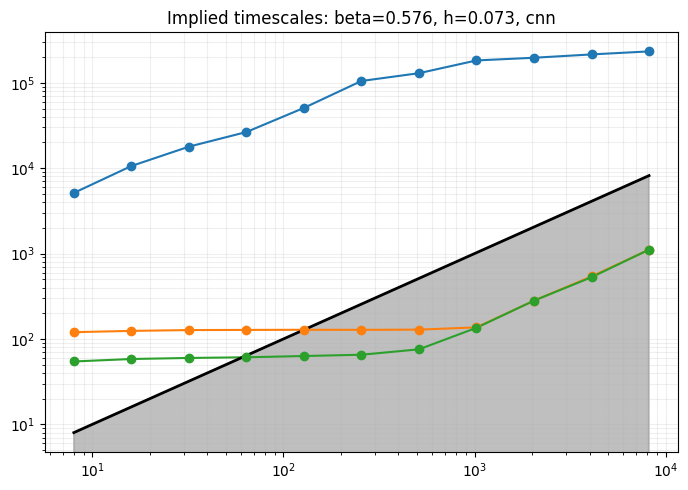

In [65]:
def deeptime_implied_timescale_plot(beta, h, rc="cnn", n_its=3, retention_threshold=0.5):
    lags = available_count_lags(beta, h, rc)
    lagtimes = []
    timescales = []

    for lagtime in lags:
        C_raw = load_count_matrix(beta, h, rc, lagtime)
        coarse_choice = choose_coarse_graining(C_raw, retention_threshold=retention_threshold)
        C = coarse_grain_first_n_states(C_raw, coarse_choice["n_combine"])
        P = count_to_transition(C, normalize_rows=True)
        msm = MarkovStateModel(transition_matrix=P, lagtime=lagtime, reversible=False)

        lagtimes.append(lagtime)
        timescales.append(np.asarray(msm.timescales()[:n_its], dtype=float))

    its_data = ImpliedTimescales(lagtimes, timescales)
    fig, ax = plt.subplots(figsize=(7, 5))
    plot_implied_timescales(
        its_data,
        n_its=n_its,
        show_samples=False,
        show_sample_mean=False,
        show_sample_confidence=False,
        ax=ax,
    )

    ts_array = np.asarray(timescales, dtype=float)
    for i in range(min(n_its, ts_array.shape[1])):
        ax.scatter(lagtimes, ts_array[:, i], s=36, marker="o", zorder=4)

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title(f"Implied timescales: beta={beta:.3f}, h={h:.3f}, {rc}")
    ax.grid(True, which="both", alpha=0.2)
    plt.tight_layout()
    return fig, ax, its_data


fig, ax, its_data = deeptime_implied_timescale_plot(0.576, 0.073, rc="cnn", n_its=3)